## AMS 518. Homework 4
### Juan Perez Osorio - SBU ID: 116248538

### **Part 1**

1. Download SP500 and IBM end of the day data for the recent 5 years from Brightspace

We execute the following in R

~~~R
> # Load the data 
> SP500IBM <- read.csv("C:/Users/Jujop/Documents/GitHub/
                            ams-518/homework-4/data/sp500_ibm_close.csv")
~~~

2. Build design matrix: I generated two matrices: one containing monthly returns and one with the daily returns, I want to run the analysis on both.

* dependent variable = IBM daily return
* independent variable (factor) = SP500 daily return

~~~R
# Reorder the columns to generate the design matrix (the dependent variable-IBM
# first and the independent variable-SP500-is last)

> design_matrix <- SP500IBM[, c(1, 3, 2)]
# Calculate simple daily returns
> design_matrix$ibm_return <- c(NA, diff(design_matrix$IBM) 
    / design_matrix$IBM[-nrow(design_matrix)])
> design_matrix$sp500_return <- c(NA, diff(design_matrix$SP500) 
    / design_matrix$SP500[-nrow(design_matrix)])
> design_matrix <- design_matrix[,-c(2, 3)]
> design_matrix <- na.omit(design_matrix)

# Convert Date column to proper date format
> design_matrix$Date <- as.Date(design_matrix$Date)

# Compute monthly returns
> data_xts <- xts(design_matrix[, c("ibm_return", "sp500_return")], 
                    order.by = design_matrix$Date)

# Calculate monthly returns
> monthly_returns <- apply.monthly(data_xts, function(x) 
                    {apply(x, 2, function(column) prod(1 + column) - 1)})

# Convert back to data frame if needed
> monthly_data <- data.frame(
+   Date = index(monthly_returns),
+   coredata(monthly_returns)
+ )

# Generate two matrices: one containing monthly returns and the other daily returns
> matrix_s_daily <- design_matrix %>% mutate(intercept = 1)
> matrix_s_monthly <- monthly_data %>% mutate(intercept = 1)
> matrix_s_daily <- matrix_s_daily[, c(1, 4, 2, 3)]
> matrix_s_daily <- matrix_s_daily[, -1]
> matrix_s_monthly <- matrix_s_monthly[, c(1, 4, 2, 3)]
> matrix_s_monthly <- matrix_s_monthly[, -1]

# Be aware that in PSG all the matrices we define have to start by matrix_...
> matrix_s_monthly <- as.matrix(matrix_s_monthly)
> matrix_s_daily <- as.matrix(matrix_s_daily)
> colnames(matrix_s_daily)[2] <- "scenario_benchmark"
> colnames(matrix_s_monthly)[2] <- "scenario_benchmark"
~~~

3. Conduct quantile regression and estimate 50% and 85% quantile of IBM return as a function of the SP500 return.

**For daily returns we have**    
- 50% quantile

~~~R
> problem.list <- problem.list[-3]
# Reassign and correctly define the problem statement
> problem.list$problem_name <- "Quantile-regression-50%"
> problem.list$problem_statement[2] <- "kb_err(0.5, matrix_s_daily)"
# Reassign the design matrix
> problem.list$matrix_s_daily <- matrix_s_daily
~~~

We obtain the following results

~~~R
# Run PSG Solver to optimize problem stored in problem.list
> results_0.5_daily <- rpsg_solver(problem.list)
Data successfully read from C:\Aorda\PSG25\PSG25_license.bin
Running solver
Reading problem formulation
Asking for data information
Getting data
100% of matrix_s_daily was read
Start optimization
Ext.iteration=0  Objective=0.516402958706E-02  Residual=0.000000000000E+00
Ext.iteration=47  Objective=0.433829015481E-02  Residual=0.000000000000E+00
Optimization is stopped
Solution is optimal
Calculating resulting outputs. Writing solution.
Objective: objective = 4.338290154813E-03 [-3.469446951954E-18]
Solver has normally finished. Solution was saved.
Problem: problem_1, solution_status = optimal
Timing: data_loading_time = 0.05, preprocessing_time = 0.01, solving_time = 0.01
Variables: optimal_point = point_problem_1
Objective: objective = 4.338290154813E-03 [-3.469446951954E-18]
Function: kb_err(0.5,matrix_s_daily) =  4.338290154813E-03
Function: pseudo_R2_kb_err(0.5,matrix_s_daily) =  1.560846804067E-01
Function: adjusted_pseudo_R2_kb_err(0.5,matrix_s_daily) =  1.567576591304E-01
Function: contributions(kb_err(0.5,matrix_s_daily)) = point_contributions_kb_err
OK. Solver Finished
~~~

We can note that the solver solution is optimal and the results are as follows:

~~~R
> results_0.5_daily$point_problem_1
   intercept sp500_return 
0.0002981778 0.6267634427 
~~~

Hence we have that 

$$\operatorname{IBM}_{ret} = 0.0002981778 + 0.6267634427 \cdot \operatorname{SP500}_{ret}$$

   - 85% quantile

~~~R
> problem.list <- problem.list[-3]
> # Reassign and correctly define the problem statement
> problem.list$problem_name <- "Quantile-regression-85%"
> # Reassign and correctly define the problem statement
> problem.list$problem_name <- "Quantile-regression-85%"
> problem.list$problem_statement[2] <- "kb_err(0.85, matrix_s_daily)"
> # Reassign the design matrix
> problem.list$matrix_s_daily <- matrix_s_daily
> # Run PSG Solver to optimize problem stored in problem.list
> results_0.85_daily <- rpsg_solver(problem.list)
Data successfully read from C:\Aorda\PSG25\PSG25_license.bin
Running solver
Reading problem formulation
Asking for data information
Getting data
     33.3% of scenarios is processed
100% of matrix_s_daily was read
Start optimization
Ext.iteration=0  Objective=0.545398621149E-02  Residual=0.000000000000E+00
Ext.iteration=67  Objective=0.282304956492E-02  Residual=0.000000000000E+00
Optimization is stopped
Solution is optimal
Calculating resulting outputs. Writing solution.
Objective: objective = 2.823049564922E-03 [4.336808689942E-19]
Solver has normally finished. Solution was saved.
Problem: problem_1, solution_status = optimal
Timing: data_loading_time = 0.10, preprocessing_time = 0.01, solving_time = 0.01
Variables: optimal_point = point_problem_1
Objective: objective = 2.823049564922E-03 [4.336808689942E-19]
Function: kb_err(0.85,matrix_s_daily) =  2.823049564922E-03
Function: pseudo_R2_kb_err(0.85,matrix_s_daily) =  1.268717276706E-01
Function: adjusted_pseudo_R2_kb_err(0.85,matrix_s_daily) =  1.275680022099E-01
Function: contributions(kb_err(0.85,matrix_s_daily)) = point_contributions_kb_err
OK. Solver Finished
~~~

We can check the results as follows

~~~R
> results_0.85_daily$point_problem_1
   intercept sp500_return 
  0.01070447   0.60241469
~~~

Hence we have that 

$$\operatorname{IBM}_{ret} = 0.01070447 + 0.60241469 \cdot \operatorname{SP500}_{ret}$$

We sotre the regression results as follows:

~~~R
# Store regression coefficients
intercept_0.5_daily <- results_0.5_daily$point_problem_1[1]
slope_0.5_daily <- results_0.5_daily$point_problem_1[2]

intercept_0.85_daily <- results_0.85_daily$point_problem_1[1]
slope_0.85_daily <- results_0.85_daily$point_problem_1[2]
~~~

**Monthly returns**

We do the same again to compute the monthly returns regression coefficients

* 50% quantile

~~~R
> # Run again for the monthly returns
> problem.list <- problem.list[-3]
> # Reassign and correctly define the problem statement
> problem.list$problem_name <- "Quantile-regression-50%"
> problem.list$problem_statement[2] <- "kb_err(0.5, matrix_s_monthly)"
> # Reassign the design matrix
> problem.list$matrix_s_monthly <- matrix_s_monthly
> # Run PSG Solver to optimize problem stored in problem.list
> results_0.5_monthly <- rpsg_solver(problem.list)
Data successfully read from C:\Aorda\PSG25\PSG25_license.bin
Running solver
Reading problem formulation
Asking for data information
Getting data
     33.3% of scenarios is processed
100% of matrix_s_monthly was read
Start optimization
Ext.iteration=0  Objective=0.289311353771E-01  Residual=0.000000000000E+00
Ext.iteration=31  Objective=0.241153532684E-01  Residual=0.000000000000E+00
Optimization is stopped
Solution is optimal
Calculating resulting outputs. Writing solution.
Objective: objective = 2.411535326838E-02 [1.734723475977E-17]
Solver has normally finished. Solution was saved.
Problem: problem_1, solution_status = optimal
Timing: data_loading_time = 0.05, preprocessing_time = 0.01, solving_time = 0.01
Variables: optimal_point = point_problem_1
Objective: objective = 2.411535326838E-02 [1.734723475977E-17]
Function: kb_err(0.5,matrix_s_monthly) =  2.411535326838E-02
Function: pseudo_R2_kb_err(0.5,matrix_s_monthly) =  1.490668007522E-01
Function: adjusted_pseudo_R2_kb_err(0.5,matrix_s_monthly) =  1.632490207396E-01
Function: contributions(kb_err(0.5,matrix_s_monthly)) = point_contributions_kb_err
OK. Solver Finished
~~~

Checking the returns we obtain:

~~~R
> results_0.5_monthly$point_problem_1
   intercept sp500_return 
  0.00634518   0.87149471
~~~

Hence we have that 

$$\operatorname{IBM}_{ret} = 0.00634518 + 0.87149471 \cdot \operatorname{SP500}_{ret}$$

* 85% quantile

~~~R
> # For 85% quantile we have that
> problem.list <- problem.list[-3]
> # Reassign and correctly define the problem statement
> problem.list$problem_name <- "Quantile-regression-85%"
> problem.list$problem_statement[2] <- "kb_err(0.85, matrix_s_monthly)"
> # Reassign the design matrix
> problem.list$matrix_s_monthly <- matrix_s_monthly
> # Run PSG Solver to optimize problem stored in problem.list
> results_0.85_monthly <- rpsg_solver(problem.list)
Data successfully read from C:\Aorda\PSG25\PSG25_license.bin
Running solver
Reading problem formulation
Asking for data information
Getting data
     33.3% of scenarios is processed
100% of matrix_s_monthly was read
Start optimization
Ext.iteration=0  Objective=0.349868531114E-01  Residual=0.000000000000E+00
Ext.iteration=30  Objective=0.148426388203E-01  Residual=0.000000000000E+00
Optimization is stopped
Solution is optimal
Calculating resulting outputs. Writing solution.
Objective: objective = 1.484263882028E-02 [3.469446951954E-18]
Solver has normally finished. Solution was saved.
Problem: problem_1, solution_status = optimal
Timing: data_loading_time = 0.05, preprocessing_time = 0.01, solving_time = 0.01
Variables: optimal_point = point_problem_1
Objective: objective = 1.484263882028E-02 [3.469446951954E-18]
Function: kb_err(0.85,matrix_s_monthly) =  1.484263882028E-02
Function: pseudo_R2_kb_err(0.85,matrix_s_monthly) =  1.636552080625E-01
Function: adjusted_pseudo_R2_kb_err(0.85,matrix_s_monthly) =  1.775942879281E-01
Function: contributions(kb_err(0.85,matrix_s_monthly)) = point_contributions_kb_err
OK. Solver Finished
~~~

Checking the returns we obtain:

~~~R
> results_0.85_monthly$point_problem_1
   intercept sp500_return 
  0.08570787   0.81961230
~~~

Hence we have that 

$$\operatorname{IBM}_{ret} = 0.08570787 + 0.8196123 \cdot \operatorname{SP500}_{ret}$$

Again, we store the regression coefficients for the monthly returns

~~~R
> # Store regression coefficients
> intercept_0.5_monthly <- results_0.5_monthly$point_problem_1[1]
> slope_0.5_monthly <- results_0.5_monthly$point_problem_1[2]
> intercept_0.85_monthly <- results_0.85_monthly$point_problem_1[1]
> slope_0.85_monthly <- results_0.85_monthly$point_problem_1[2]
~~~

4. Plot the returns of the two assets in x-y plane (return of SP500- return of IBM). Plot the two linear quantile functions from previous question (horizontally: return of SP500 and vertically: 50% and 85% quantile of IBM).

~~~R
# Extract the returns
sp500_returns <- matrix_s_daily[, "sp500_return"]
ibm_daily_returns <- matrix_s_daily[, "scenario_benchmark"]

sp500_monthly_returns <- matrix_s_monthly[, "sp500_return"]
ibm_monthly_returns <- matrix_s_monthly[, "scenario_benchmark"]

# Set up PNG device
png("quantile_regression_daily_plot.png", 
     width = 10, height = 7, units = "in", res = 300)

# Create the scatter plot
plot(sp500_daily_returns, ibm_daily_returns, 
     xlab = "SP500 Daily Return", 
     ylab = "IBM Daily Return",
     main = "Quantile Regression: IBM vs SP500 Returns (Daily)",
     pch = 16, col = rgb(0, 0, 1, 0.2), cex = 0.7)

# Add grid for better readability
grid()

# Create x-values for the regression lines
x_range <- seq(min(sp500_daily_returns), max(sp500_daily_returns), length.out = 100)

# Calculate y-values for both quantile lines
y_50 <- intercept_0.5_daily + slope_0.5_daily * x_range
y_85 <- intercept_0.85_daily + slope_0.85_daily * x_range

# Add the quantile regression lines
lines(x_range, y_50, col = "#E69F00", lwd = 2, lty = 1)
lines(x_range, y_85, col = "#9E1C60", lwd = 2, lty = 1)

# Add legend
legend("topleft", 
       legend = c("Data points", "50% Quantile", "85% Quantile"),
       col = c(rgb(0, 0, 1, 0.5), "#E69F00", "#9E1C60"),
       pch = c(16, NA, NA),
       lty = c(NA, 1, 1),
       lwd = c(NA, 2, 2),
       bty = "n")

# Close the device
dev.off()

  # Set up PNG device
png("quantile_regression_monthly_plot.png", 
     width = 10, height = 7, units = "in", res = 300)

# Create the scatter plot
plot(sp500_monthly_returns, ibm_monthly_returns, 
     xlab = "SP500 Monthly Return", 
     ylab = "IBM MOnthly Return",
     main = "Quantile Regression: IBM vs SP500 Returns (Monthly)",
     pch = 16, col = rgb(1, 0, 0, 0.3), cex = 0.7)

# Add grid for better readability
grid()

# Create x-values for the regression lines
x_range <- seq(min(sp500_monthly_returns), max(sp500_monthly_returns), length.out = 100)

# Calculate y-values for both quantile lines
y_50 <- intercept_0.5_monthly + slope_0.5_monthly * x_range
y_85 <- intercept_0.85_monthly + slope_0.85_monthly * x_range

# Add the quantile regression lines
lines(x_range, y_50, col = "#E69F00", lwd = 2, lty = 1)
lines(x_range, y_85, col = "#9E1C60", lwd = 2, lty = 1)

# Add legend
legend("topleft", 
       legend = c("Data points", "50% Quantile", "85% Quantile"),
       col = c(rgb(0, 0, 1, 0.5), "#E69F00", "#9E1C60"),
       pch = c(16, NA, NA),
       lty = c(NA, 1, 1),
       lwd = c(NA, 2, 2),
       bty = "n")

# Close the device
dev.off()
~~~

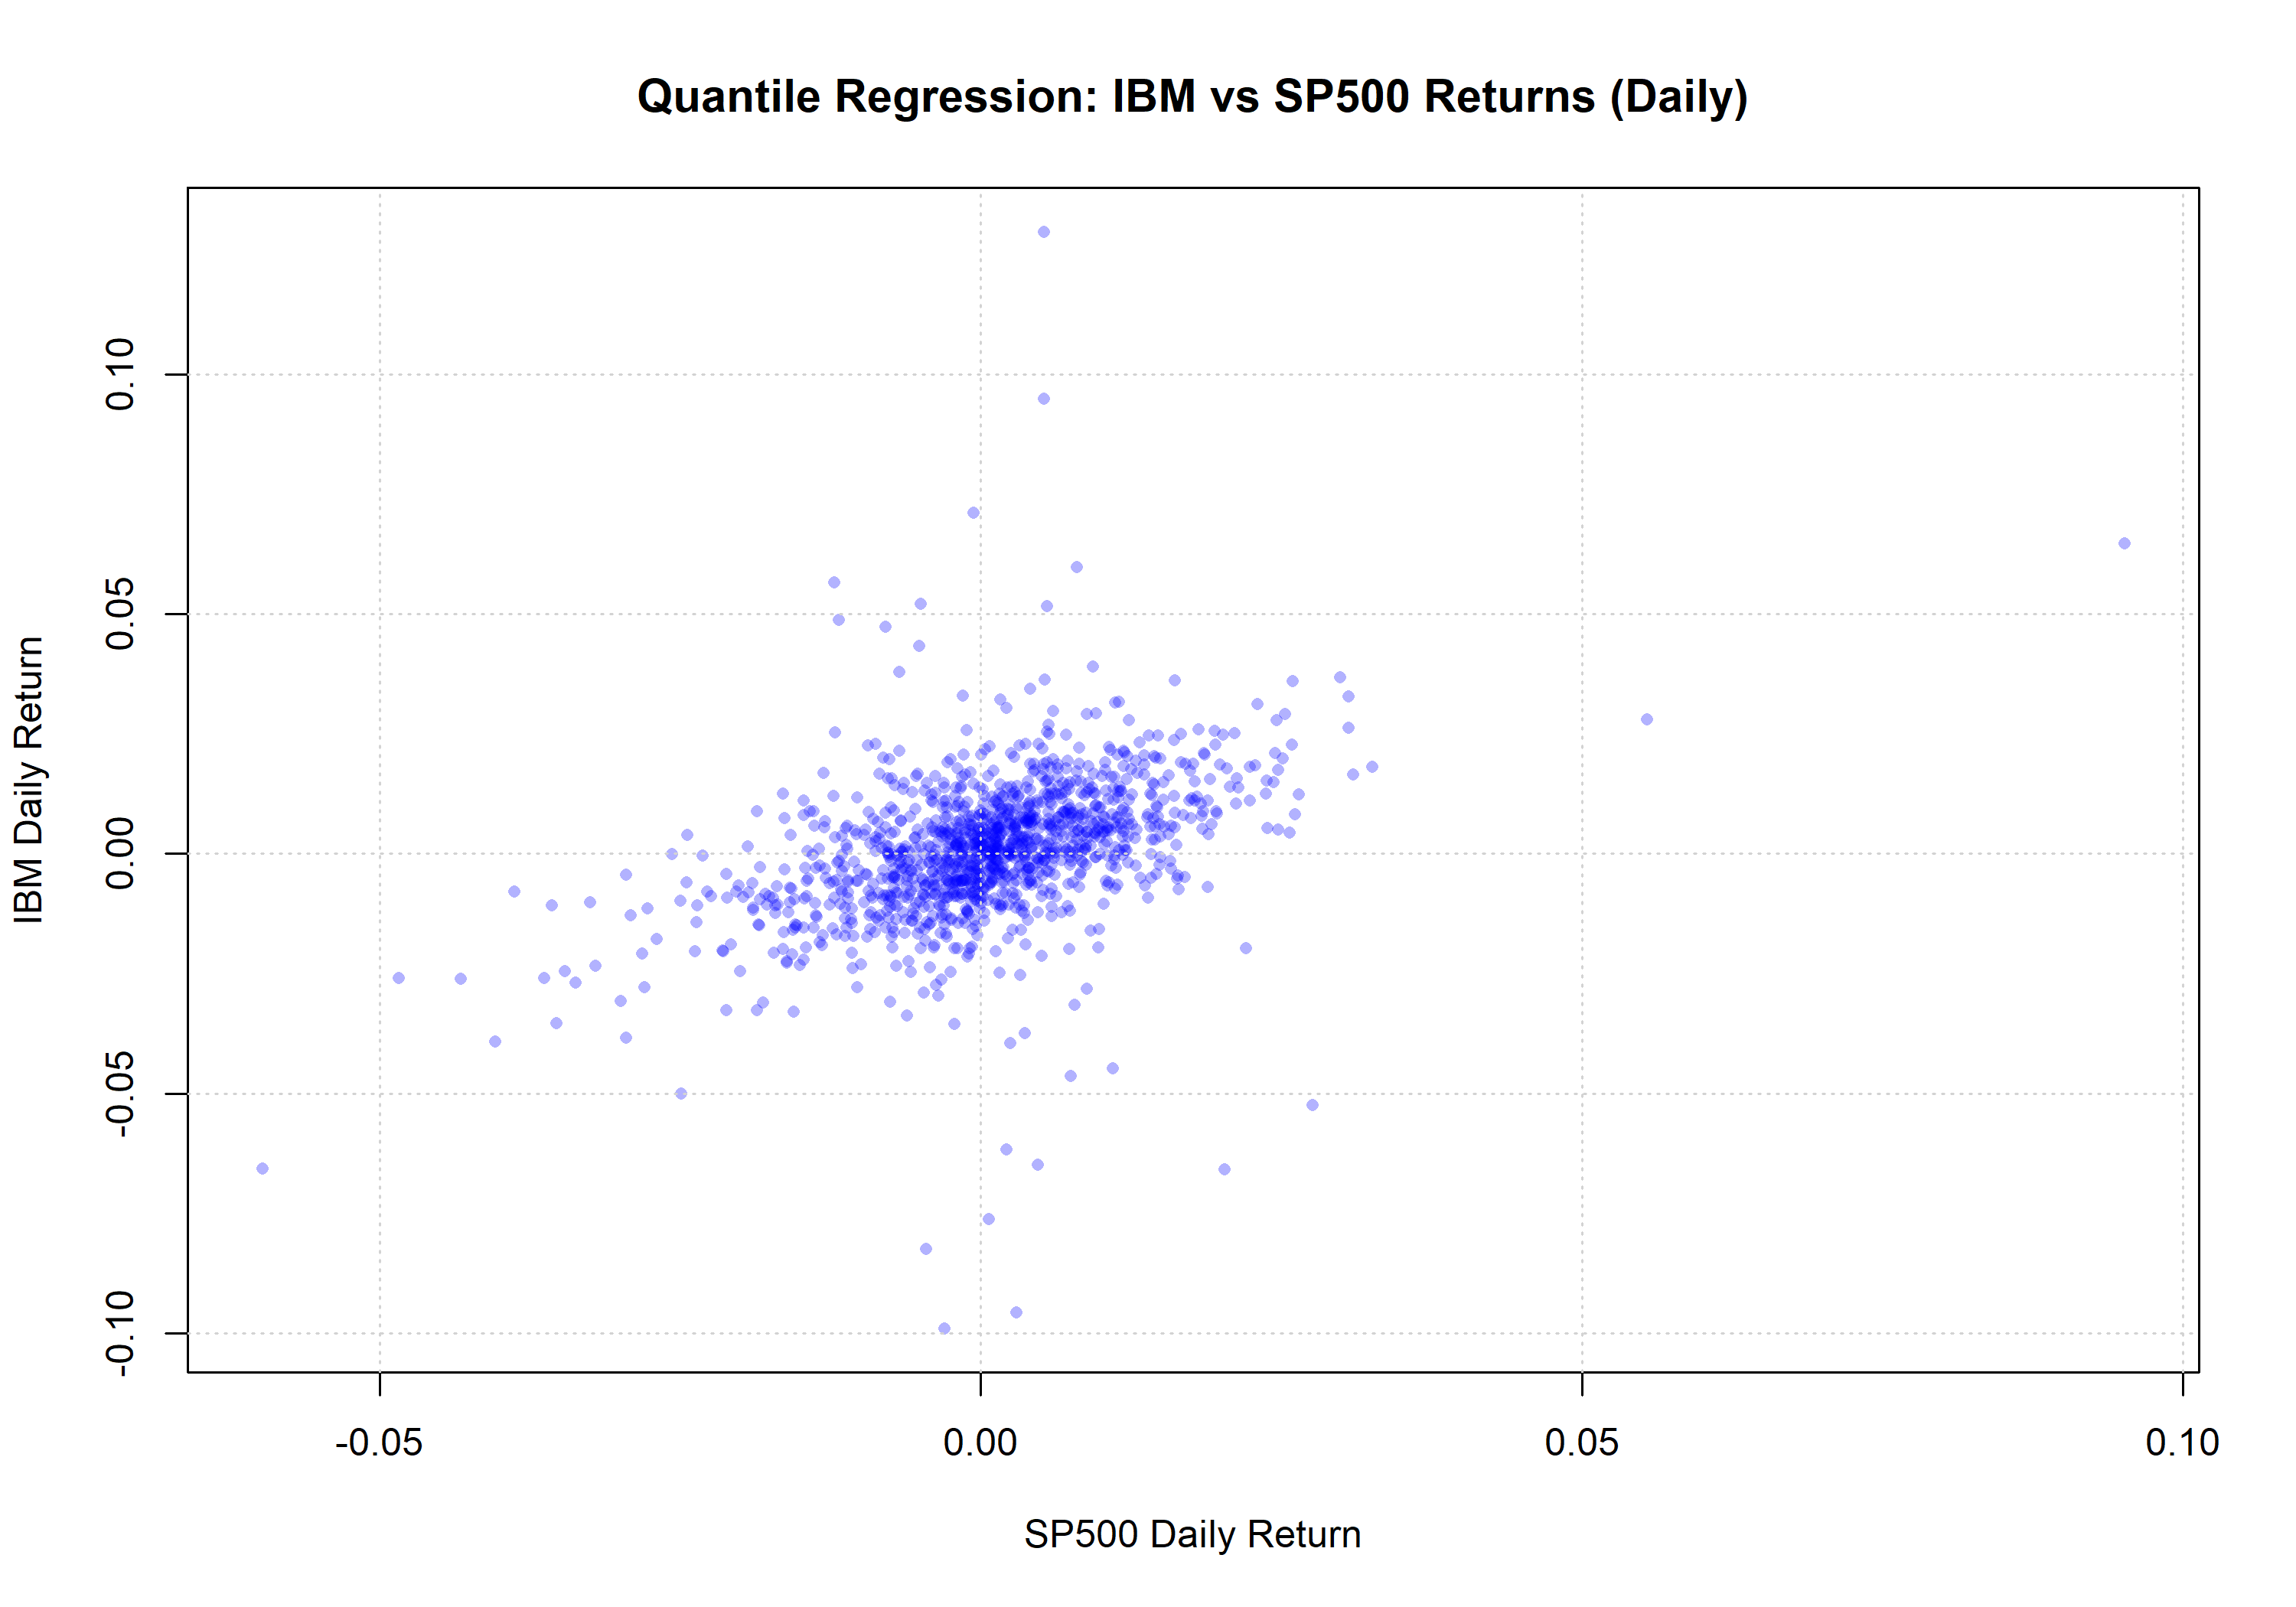

In [8]:
from IPython.display import display, Image

display(Image(filename="data/asset_daily_returns_plot.png"))

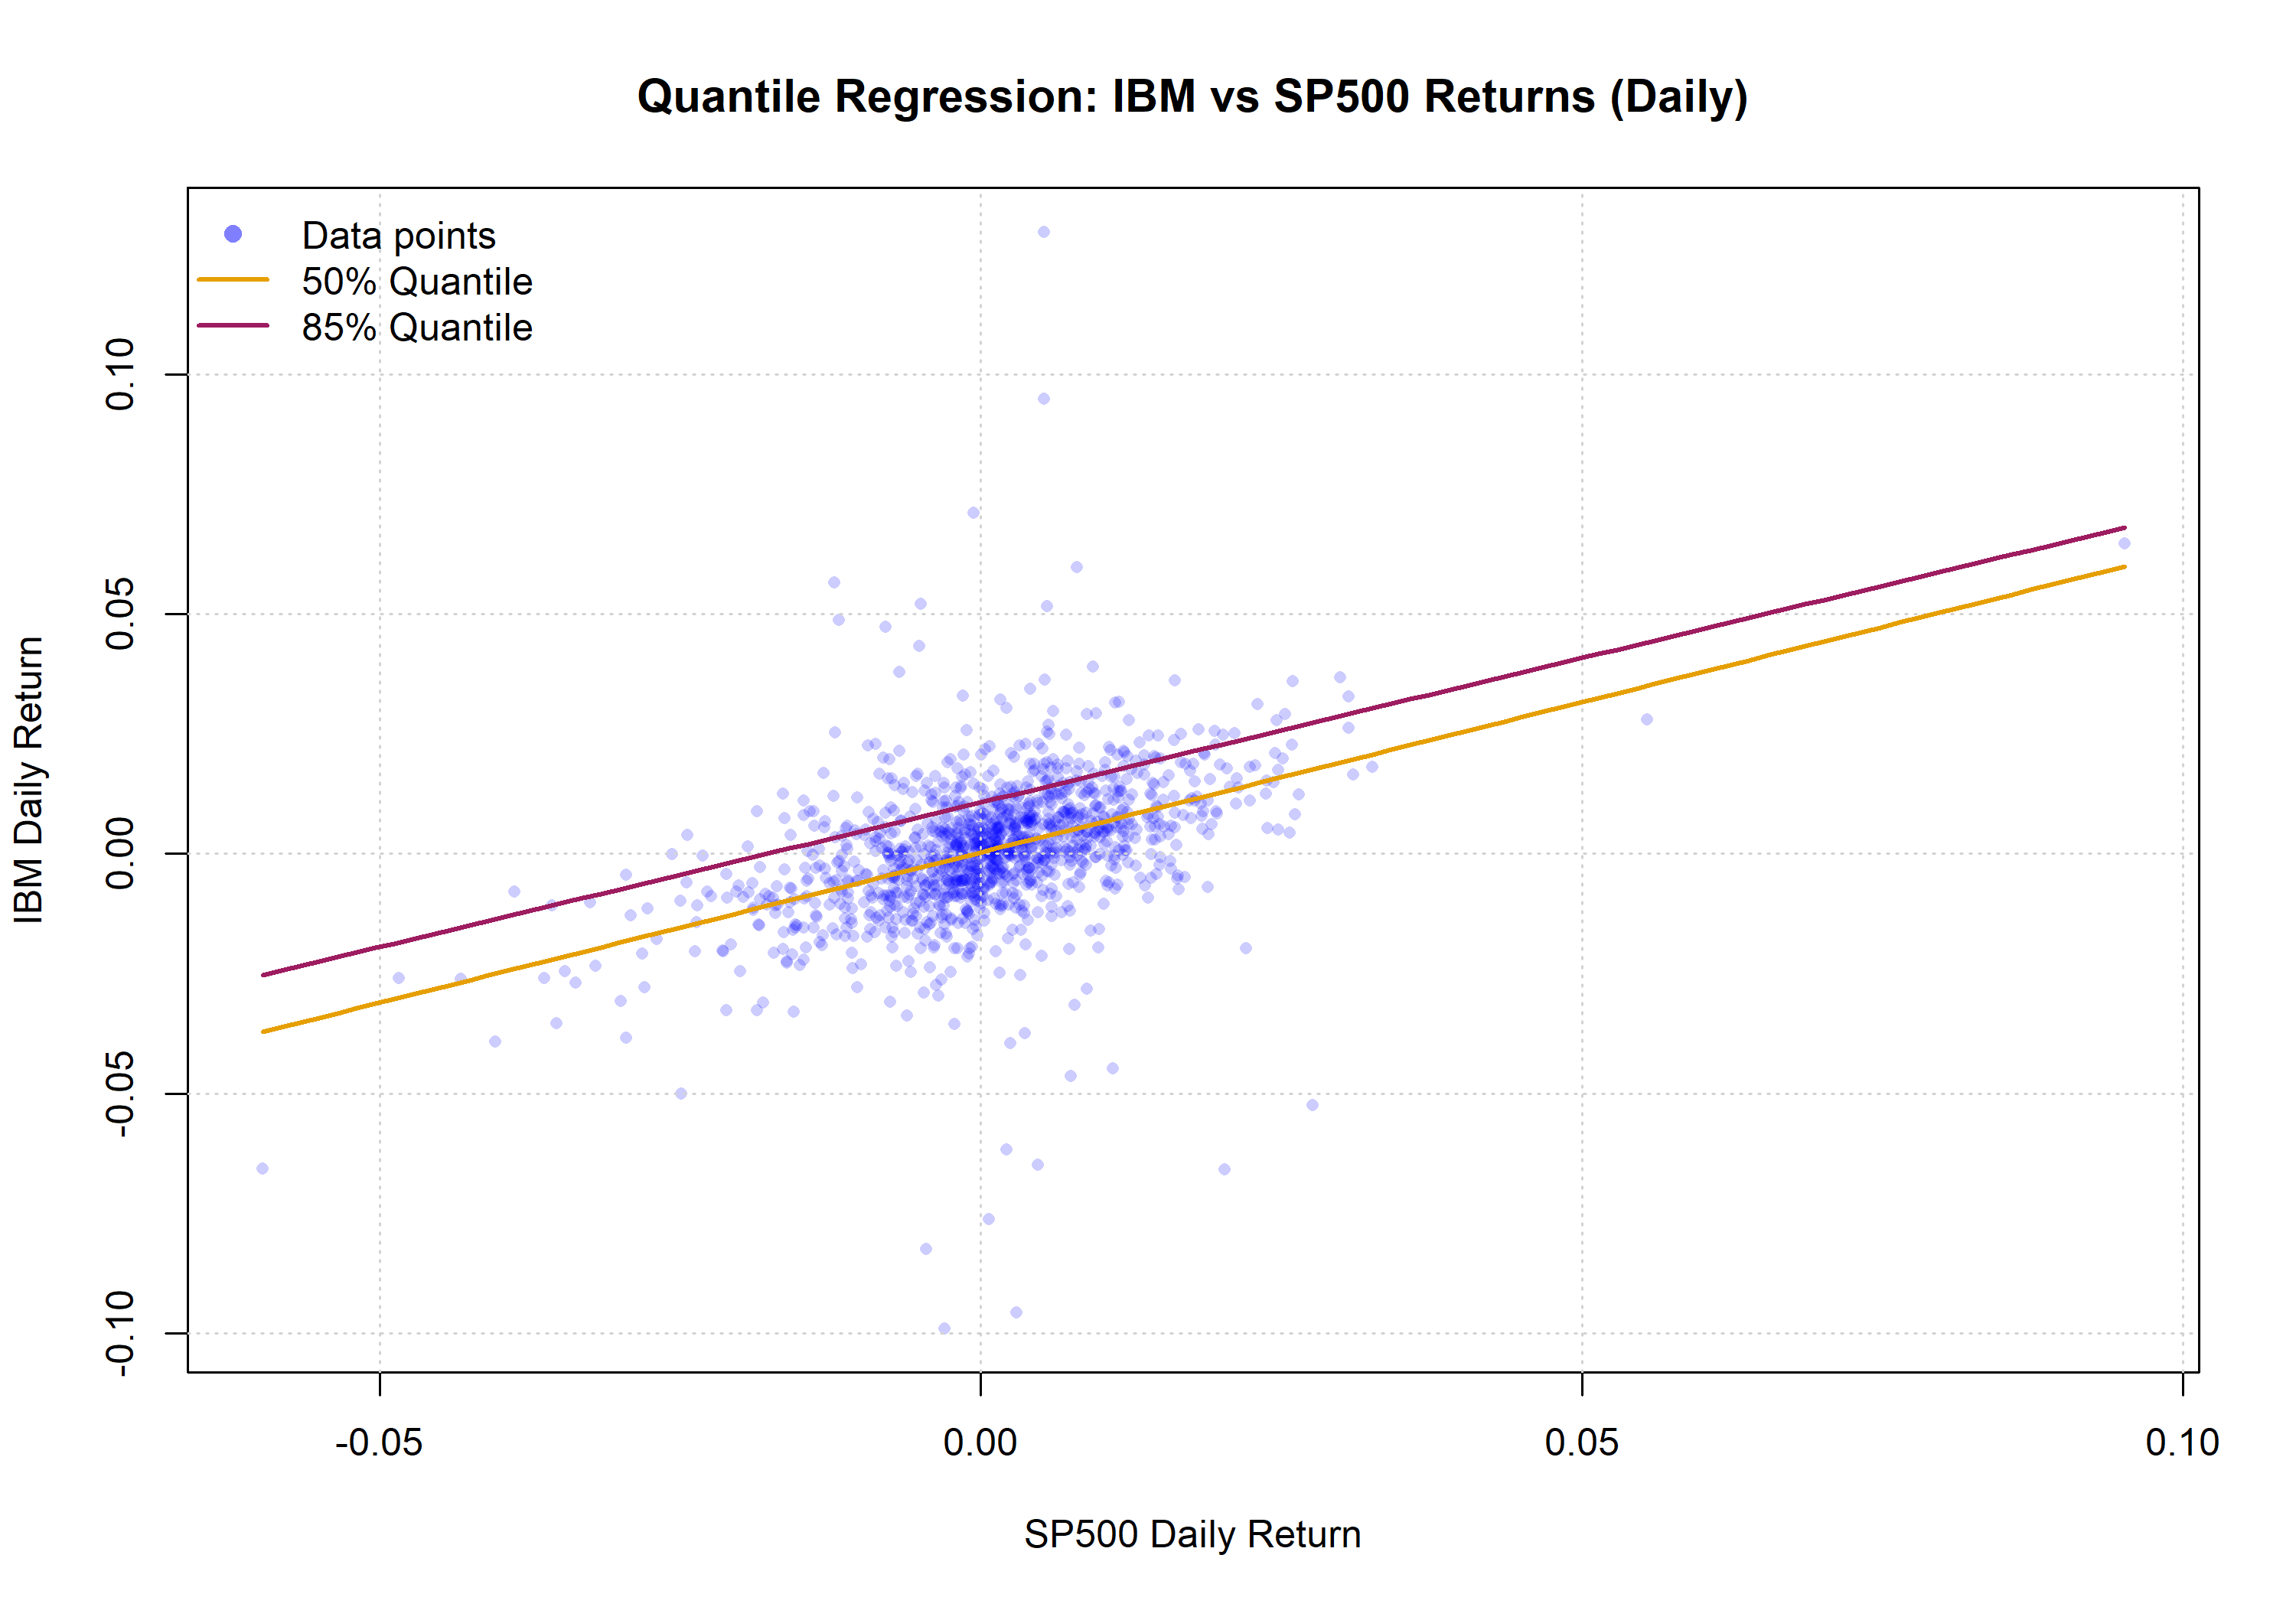

In [15]:
from IPython.display import display, Image

display(Image(filename="data/quantile_regression_daily_plot.png"))

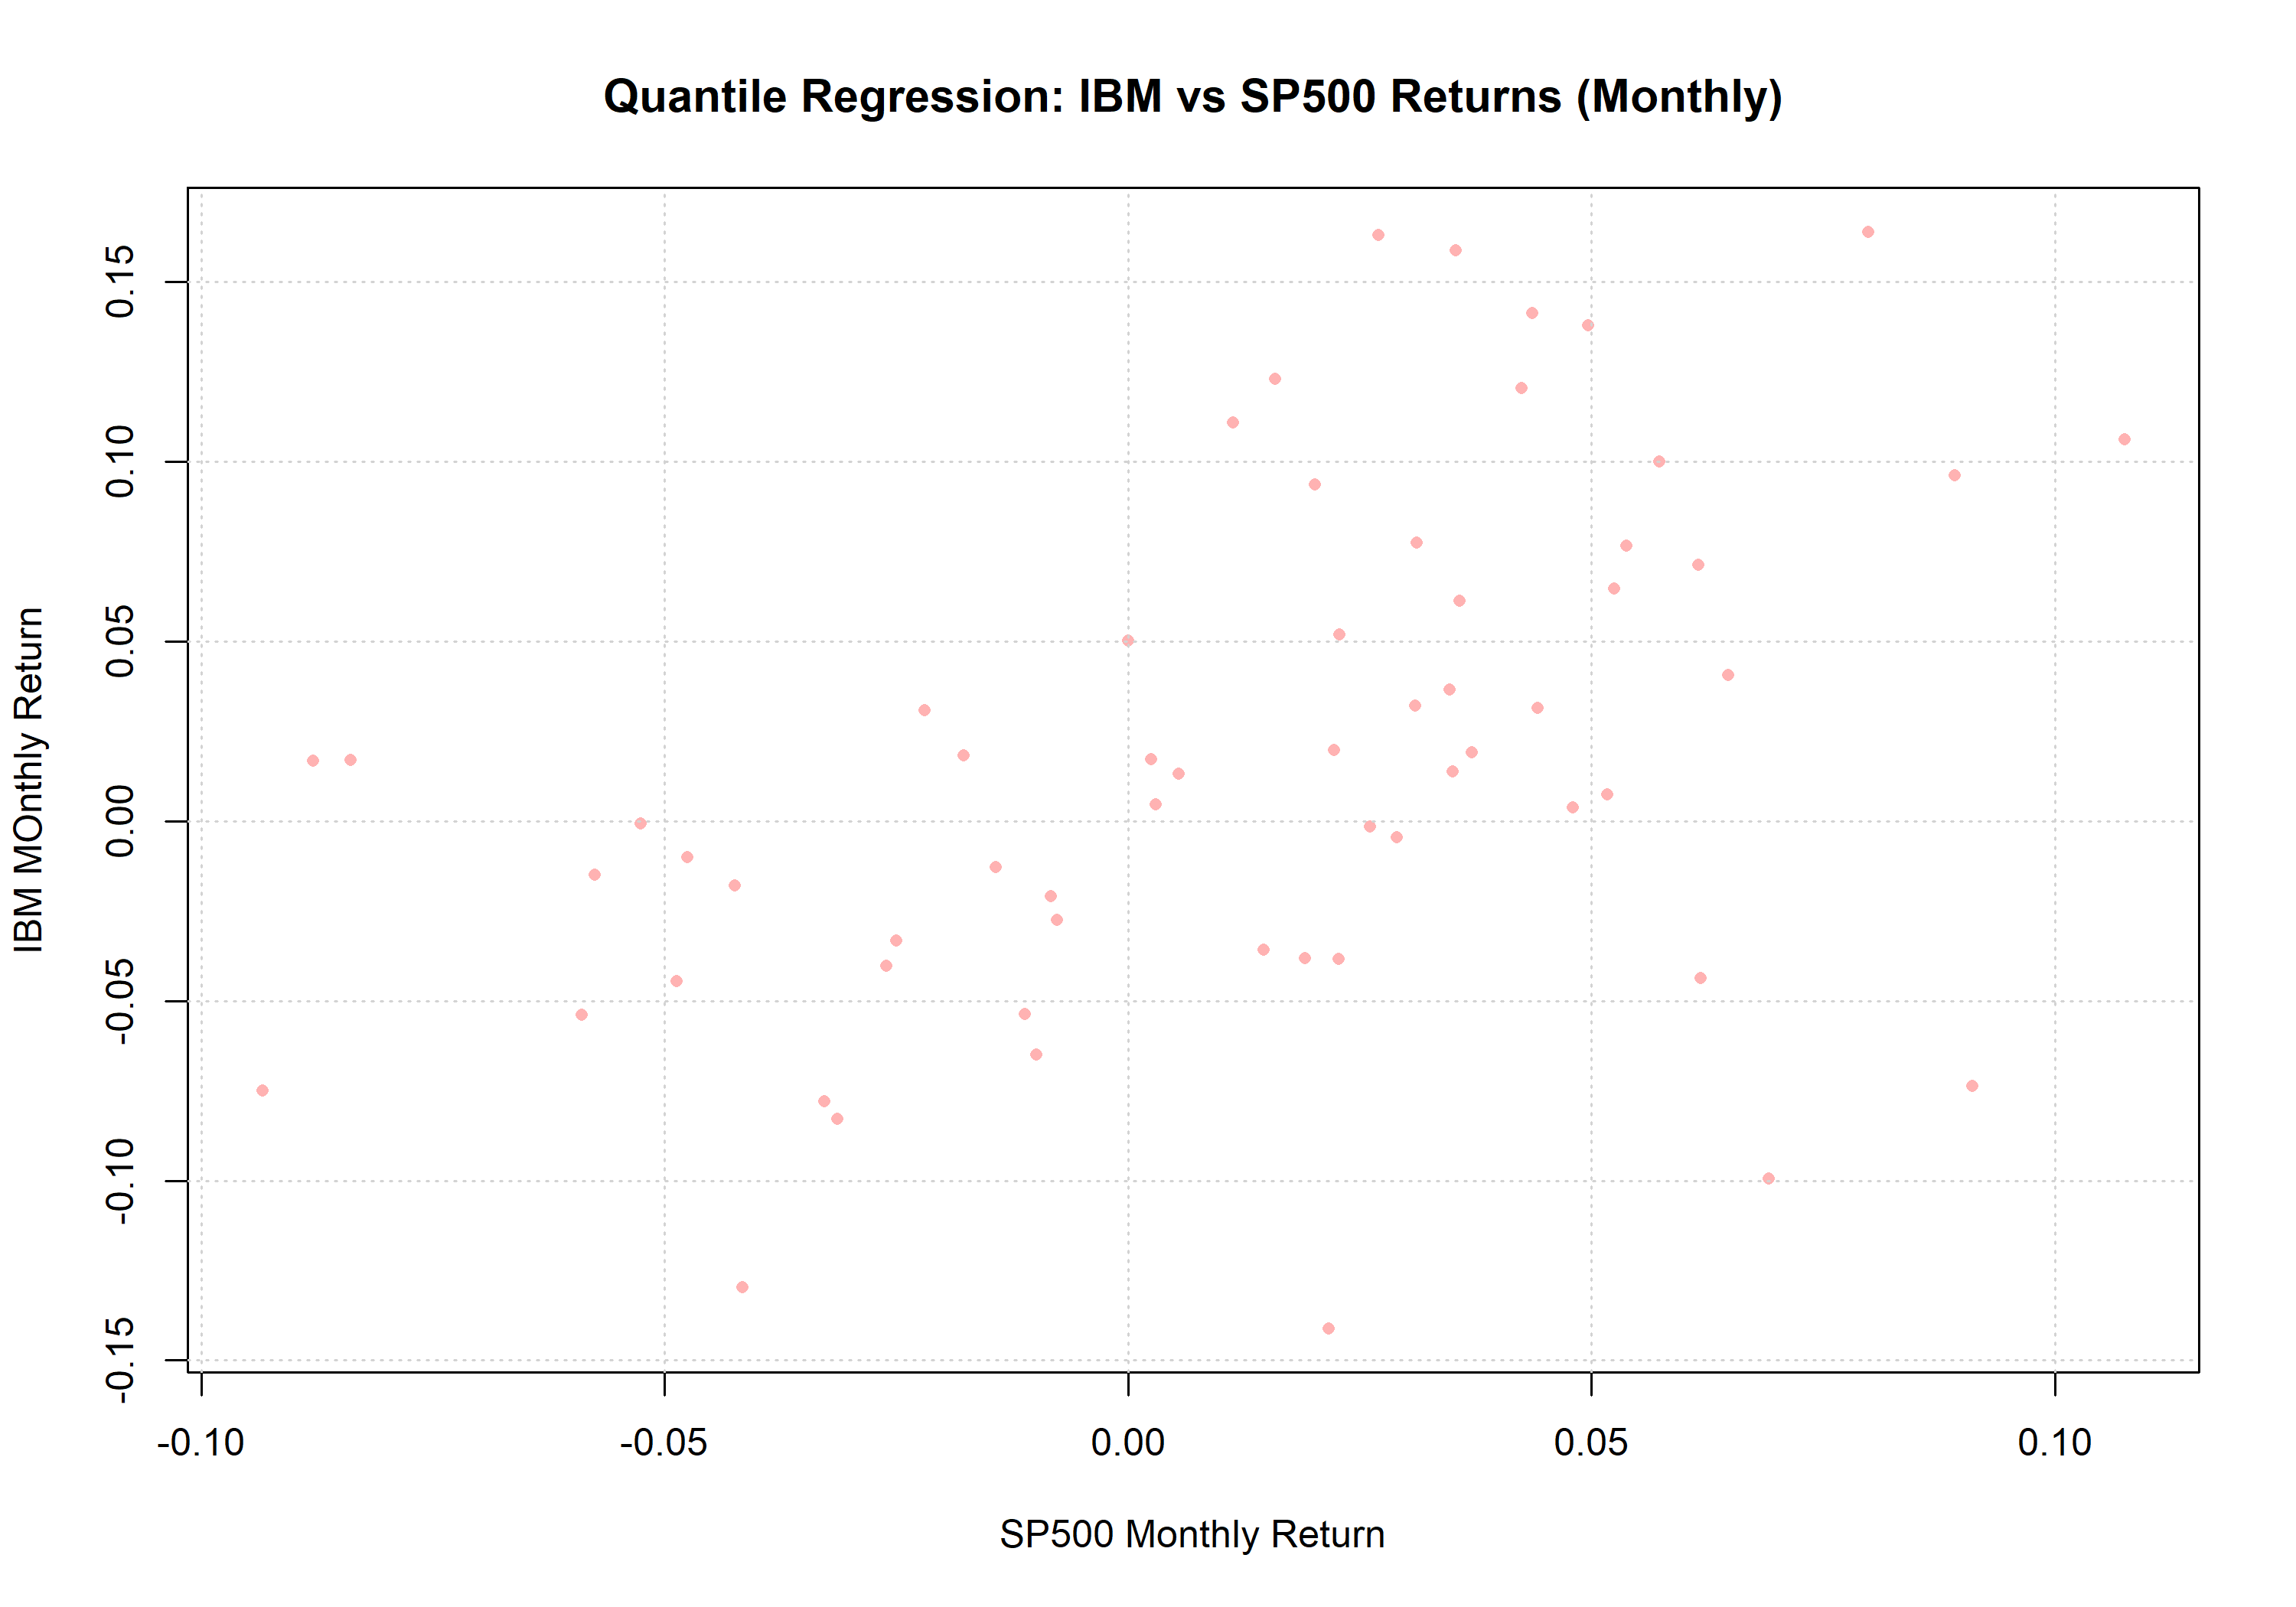

In [10]:
from IPython.display import display, Image

display(Image(filename="data/asset_monthly_returns_plot.png"))

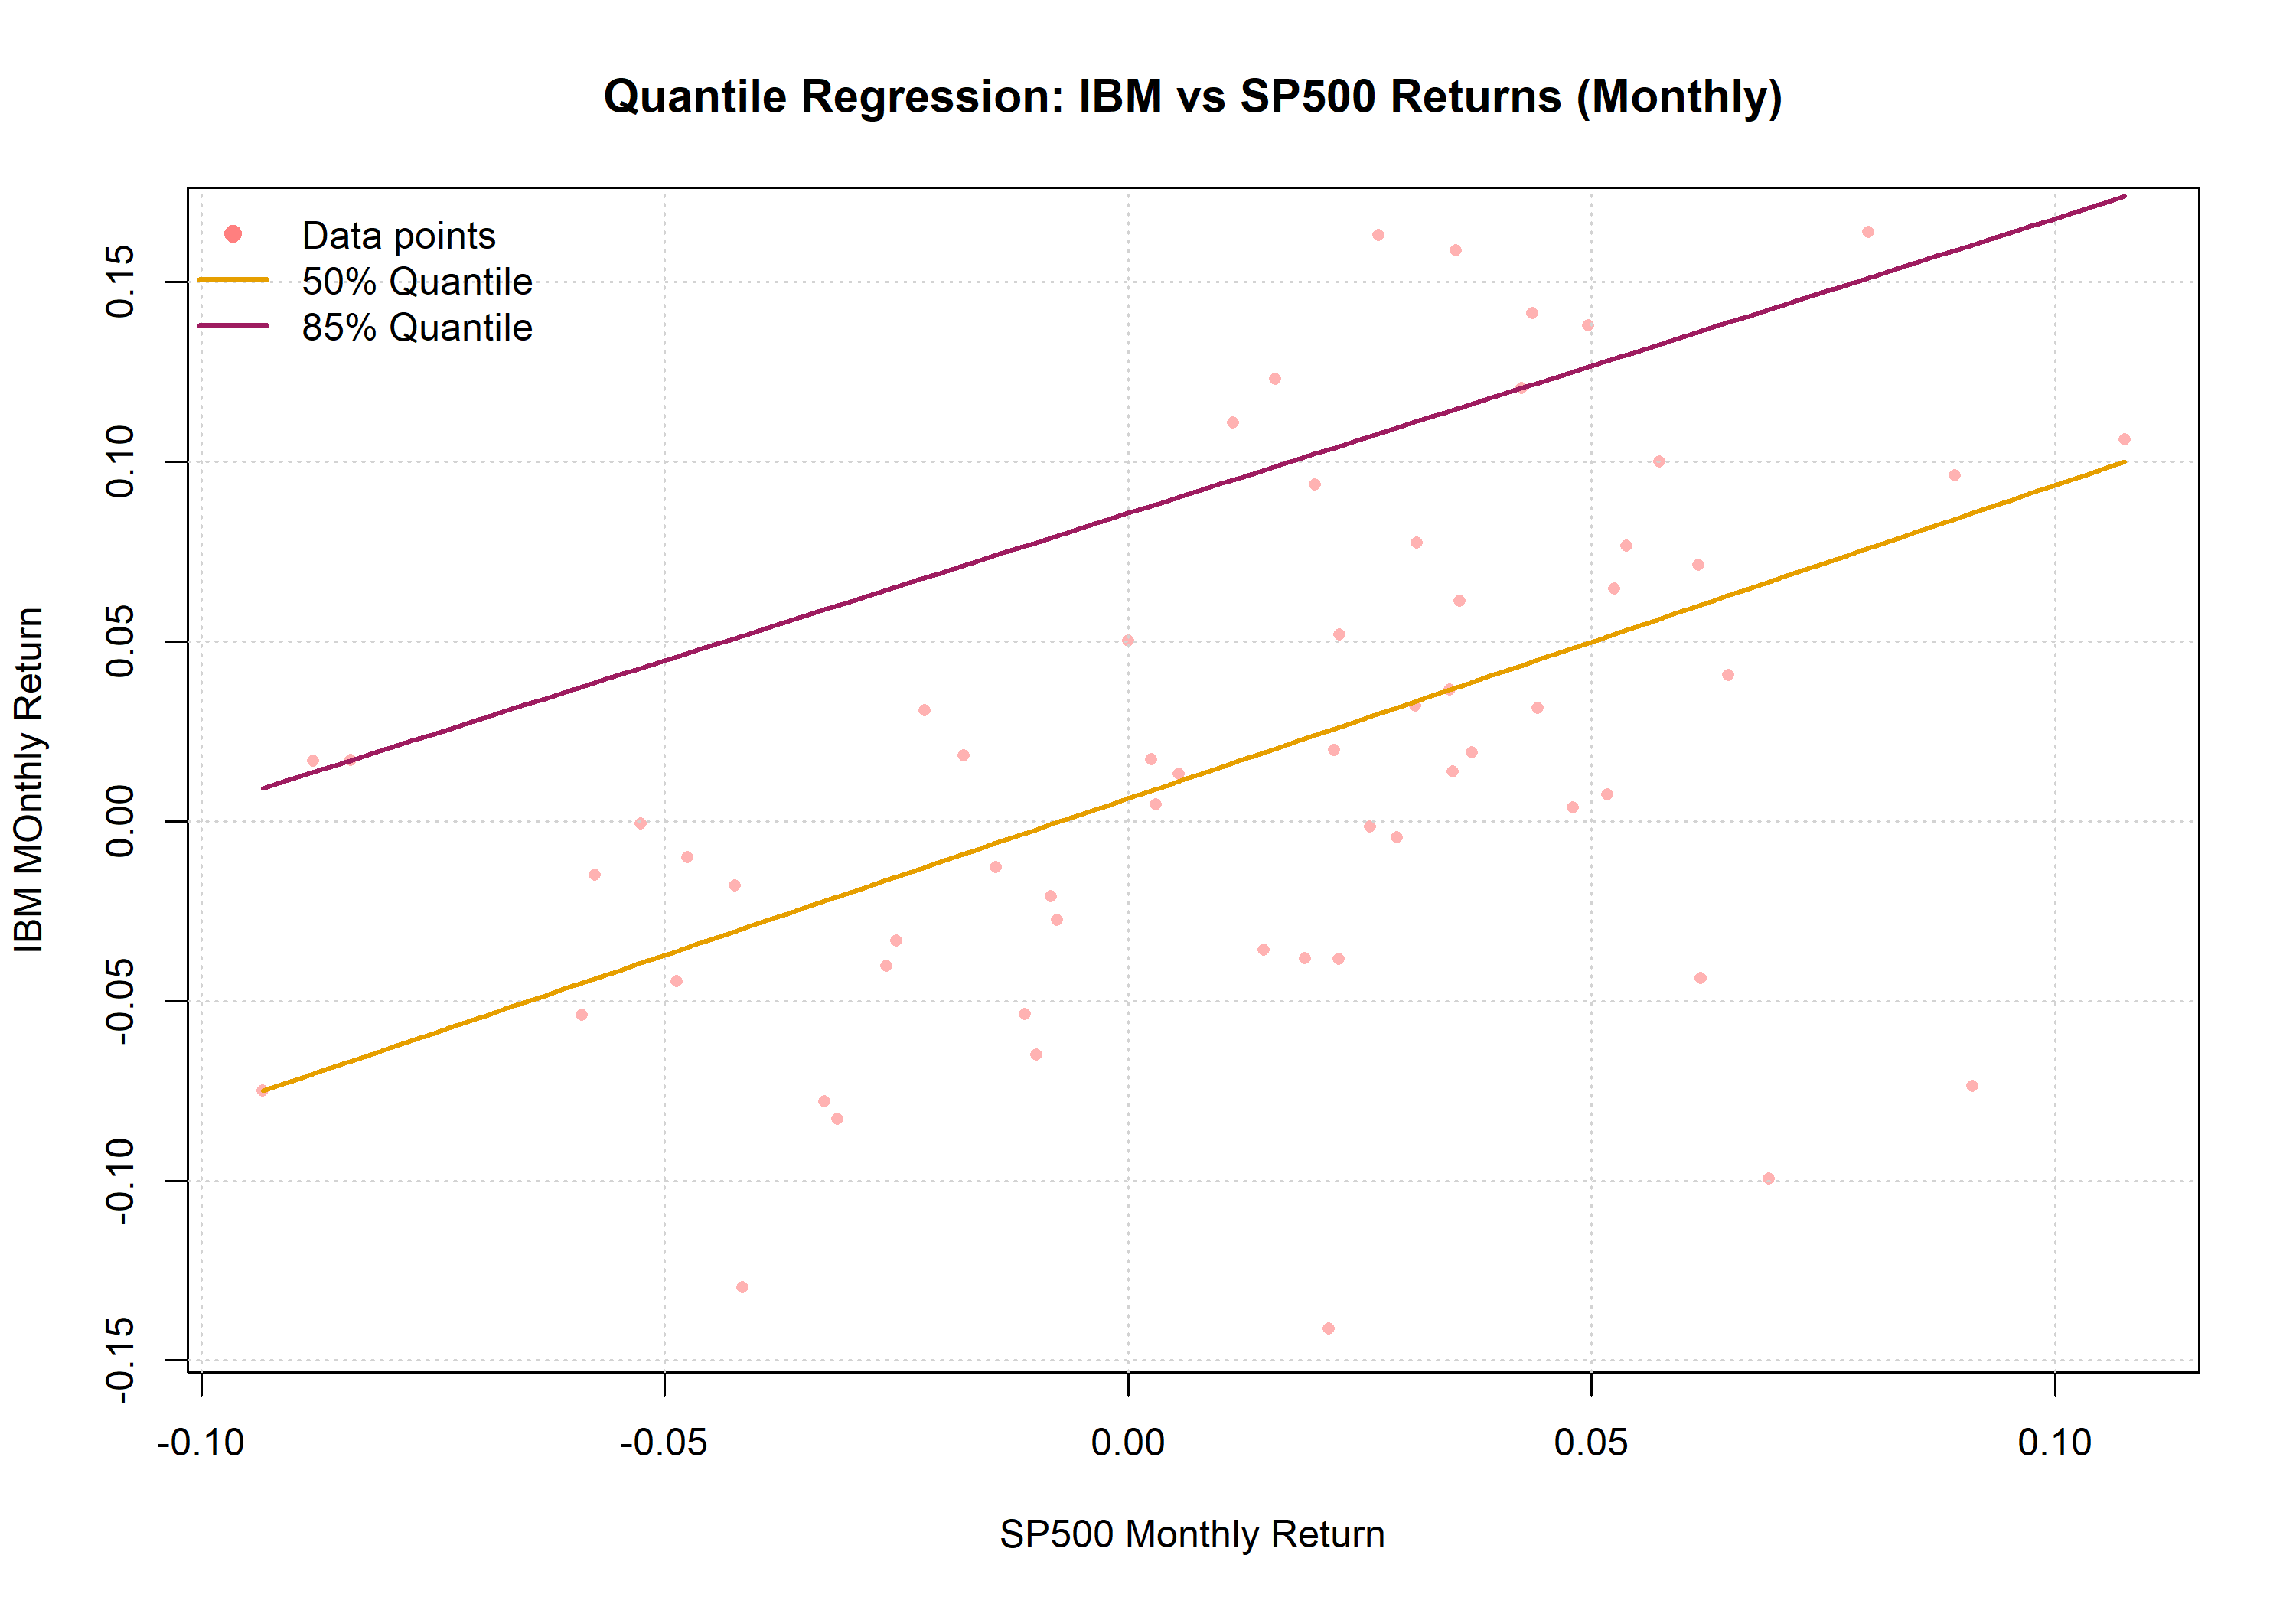

In [13]:
from IPython.display import display, Image

display(Image(filename="data/quantile_regression_monthly_plot.png"))

 5. Reproduce results of 85% quantile regression with two-step Decomposition of Regression procedure.

In this case we are going to run the optimization to compute the 0.85 CVaR and then compare this solution with the one given by the quantile regression. By the Error-Shaping Decomposition of Regression Theorem we can find an equivalent solution to the quadrangle regression by following this steps:

**Step 1:** Find an optimal vector $\vec{x^*}$ by minimizing the deviation

$$\min_{\vec{x}} \left\{ \text{cvar\_dev}_\alpha \left( L(\vec{x}, \vec{\theta}) \right) \right\}$$

**Step 2:** Assign $x^*_0$

$$x_0^* = \text{var\_risk}_\alpha \left( L(\vec{x}^*, \vec{\theta}) \right)$$

First we need to modify the problem statement to be the following:

~~~R
'''minimize
cvar_dev(0.85, matrix_s_wi)
value:
var_risk(0.85, matrix_s_wi)'''
~~~

where matrix_s_wi is the design matrix without intercept

* For our daily returns we have

~~~R
 # For 85% quantile we have that
> problem.list <- problem.list[-3]
> # Reassign and correctly define the problem statement
> problem.list$problem_name <- "CVaR-regression-85%"
> # Problem statement for cvar
> problem.list$problem_statement[1] <- "minimize"
> problem.list$problem_statement[2] <- "cvar_dev(0.85, matrix_s_daily_wi)"
> problem.list$problem_statement[3] <- "value"
> problem.list$problem_statement[4] <- "var_risk(0.85, matrix_s_daily_wi)"
> # Reassign the design matrix
> problem.list$matrix_s_daily_wi <- matrix_s_daily_wi
> results_0.85_daily_cvar <- rpsg_solver(problem.list)
Data successfully read from C:\Aorda\PSG25\PSG25_license.bin
Running solver
Reading problem formulation
Asking for data information
Getting data
     50.0% of scenarios is processed
100% of matrix_s_daily_wi was read
Start optimization
Ext.iteration=0  Objective=0.215550578641E-01  Residual=0.000000000000E+00
Ext.iteration=12  Objective=0.188203304328E-01  Residual=0.000000000000E+00
Optimization is stopped
Solution is optimal
Calculating resulting outputs. Writing solution.
Objective: objective = 1.882033043282E-02 [1.734723475977E-17]
Solver has normally finished. Solution was saved.
Problem: problem_1, solution_status = optimal
Timing: data_loading_time = 0.06, preprocessing_time = 0.01, solving_time = 0.01
Variables: optimal_point = point_problem_1
Objective: objective = 1.882033043282E-02 [1.734723475977E-17]
Function: cvar_dev(0.85,matrix_s_daily_wi) =  1.882033043282E-02
Function: var_risk(0.85,matrix_s_daily_wi) =  1.069609789460E-02
OK. Solver Finished
~~~

We obtain the following result:

~~~R
> results_0.85_daily_cvar$point_problem_1
sp500_return 
   0.6024147
~~~

We can see that this yields practically the same regression coefficient that using the other regression

~~~R
> slope_0.85_daily_cvar <- results_0.85_daily_cvar$point_problem_1
> slope_0.85_daily_cvar <- as.numeric(slope_0.85_daily_cvar)
> slope_0.85_daily <- as.numeric(slope_0.85_daily)
> diff = abs(slope_0.85_daily_cvar - slope_0.85_daily)
> diff
[1] 5.928591e-14
~~~

Now we just have to check that var_a coincides with the intercept that we already have, we can see that

~~~R
> results_0.85_daily_cvar$output[6]
[1] "Function: var_risk(0.85,matrix_s_daily_wi) =  1.069609789460E-02"

> var_risk_0.85 = 1.069609789460E-02
> intercept_0.85_daily <- as.numeric(intercept_0.85_daily)
> diff_intercept <- abs(var_risk_0.85 - intercept_0.85_daily)
> diff_intercept
[1] 8.370867e-06
~~~

* For the monthly returns we have

~~~R
> # For 85% quantile monthly we have that
> problem.list <- problem.list[-3]
> # Reassign and correctly define the problem statement
> problem.list$problem_name <- "CVaR-regression-85%"
> # Problem statement for cvar
> problem.list$problem_statement[1] <- "minimize"
> problem.list$problem_statement[2] <- "cvar_dev(0.85, matrix_s_monthly_wi)"
> problem.list$problem_statement[3] <- "value"
> problem.list$problem_statement[4] <- "var_risk(0.85, matrix_s_monthly_wi)"
> # Reassign the design matrix
> problem.list$matrix_s_monthly_wi <- matrix_s_monthly_wi
> results_0.85_monthly_cvar <- rpsg_solver(problem.list)
Data successfully read from C:\Aorda\PSG25\PSG25_license.bin
Running solver
Reading problem formulation
Asking for data information
Getting data
     50.0% of scenarios is processed
100% of matrix_s_monthly_wi was read
Start optimization
Ext.iteration=0  Objective=0.118313554915E+00  Residual=0.000000000000E+00
Ext.iteration=7  Objective=0.989509254686E-01  Residual=0.000000000000E+00
Optimization is stopped
Solution is optimal
Calculating resulting outputs. Writing solution.
Objective: objective = 9.895092546857E-02 [2.775557561563E-17]
Solver has normally finished. Solution was saved.
Problem: problem_1, solution_status = optimal
Timing: data_loading_time = 0.09, preprocessing_time = 0.01, solving_time = 0.01
Variables: optimal_point = point_problem_1
Objective: objective = 9.895092546857E-02 [2.775557561563E-17]
Function: cvar_dev(0.85,matrix_s_monthly_wi) =  9.895092546857E-02
Function: var_risk(0.85,matrix_s_monthly_wi) =  8.443137393789E-02
OK. Solver Finished

> slope_0.85_monthly_cvar <- results_0.85_monthly_cvar$point_problem_1
> slope_0.85_monthly_cvar <- as.numeric(slope_0.85_monthly_cvar)
> slope_0.85_monthly <- as.numeric(slope_0.85_monthly)
> diff = abs(slope_0.85_monthly_cvar - slope_0.85_monthly)
> diff
[1] 9.992007e-15
> slope_0.85_monthly_cvar
[1] 0.8196123
~~~

Which coincides with the coefficient obtained for the initial regression. Similarly, we can se that the intercept obtained is

~~~R
> results_0.85_monthly_cvar$output[6]
[1] "Function: var_risk(0.85,matrix_s_monthly_wi) =  8.443137393789E-02"
> var_risk_0.85_monthly = 8.443137393789E-02
> intercept_0.85_monthly <- as.numeric(intercept_0.85_monthly)
> diff_intercept <- abs(var_risk_0.85_monthly - intercept_0.85_monthly)
> diff_intercept
[1] 0.001276493
~~~

Which is a very close result to the one obtained initially

### **Part 2**

Formulate mathematically the following portfolio optimization Problem 1 and Problem 2. Prove that these two optimization problems are equivalent:

**Problem 1.** Minimize the Koenker-Bassett error with $\alpha = 0.5$:

$$\min E\left[\frac{\alpha}{1-\alpha}X^{+} + X^{-}\right]$$

Subject to:
$$E[X] = 0$$

Where:

- $\alpha = 0.5$

**Problem 2:** Minimize the mean absolute deviation around expectation:

$$\min E\left|X - E[X]\right|$$

Subject to:
$$E[X] = 0$$

---

**Solution.**

We have that for $\alpha = 0.5$,

$$\frac{\alpha}{1-\alpha} = \frac{0.5}{0.5} = 1$$

Thus, we have that problem 1 becomes

$$\min E\left[X^{+} + X^{-}\right]$$

Let's define:

- $X^{+} := \max(X, 0)$
- $X^{-} := \max(-X, 0)$

Now we can note that 

$$
\left|X\right|=\begin{cases} 
       X & X\geq 0 \\
      -X & X < 0 
   \end{cases}
$$

If $X \geq 0$, we have that 

$$ X = \max(X, 0) = X^{+}$$

similarly, if $X < 0$, we have that 

$$ X = -\max(-X, 0) = -X^{-}$$

hence, we have that

$$
\left|X\right|=\begin{cases} 
      X^{+} & X\geq 0 \\
      -X^{-} & X < 0 
   \end{cases}
$$

Let $X \in \mathbb{R}$, if $X \geq 0$ we have that $X^{-}=0$

$$ |X| = X^{+} + X^{-} = X^{+}$$

if $X < 0$ we have that $X^{+}=0$

$$ |X| = X^{+} + X^{-} = X^{-} $$

Hence, for any $X \in \mathbb{R}$ 

$$ |X| = X^{+} + X^{-}$$

and therefore, problem 1 becomes

$$\min E\left[|X|\right]$$

Similarly, the optimization for problem 2, given that $E[X] = 0$, becomes

$$E[\left|X - E[X]\right|] = E[\left|X - 0\right|] = E[|X|]$$

Note that both optimization problems reduce to

$$\min E[|X|] \quad \text{subject to} \quad E[X] = 0$$

Hence, **Problem 1 $\equiv$ Problem 2**.